<a href="https://colab.research.google.com/github/henrykibithia8-dev/DS-projests/blob/main/Support_vector_machine_and_model_tuning_practice.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score

import warnings
warnings.filterwarnings("ignore")

Generating a synthetic dataset

In [8]:
from sklearn.datasets import make_gaussian_quantiles

# Set the feature dimensionality
p = 2

# Construct the dataset
X, y = make_gaussian_quantiles(cov=3.,
                                 n_samples=1000, n_features=p,
                                 n_classes=2, random_state=1)

In [9]:
# get training and testing data
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.3, random_state=42)

Fit an SVM classifier with a linear decision boundary
We are going to fit an SVM classifier with a linear kernel. This means that we are telling the SVC to fit the data using a linear decision boundary. Let's also take a look at the accuracy score:

In [10]:
from sklearn.svm import SVC

#create svc instance
svc = SVC(kernel="linear")
#fit it ti training data
svc.fit(X_train, y_train)
#get the prediction
y_pred = svc.predict(X_test)

In [11]:
#lets print the accuracy and classification report

print("The Accuracy score of SVC is:", accuracy_score(y_test, y_pred))
print("\n\n Classification Report\n\n", classification_report(y_test, y_pred))

The Accuracy score of SVC is: 0.6133333333333333


 Classification Report

               precision    recall  f1-score   support

           0       0.58      0.83      0.68       150
           1       0.70      0.39      0.50       150

    accuracy                           0.61       300
   macro avg       0.64      0.61      0.59       300
weighted avg       0.64      0.61      0.59       300



**Plot the decision boundary for the SVC**

That accuracy score doesn't seem very good. Why do you think that is? To help us understand what's going on, we can use a visualisation.

As mentioned before, the SVC calculates and implements a  p−1  dimensional decision boundary (hyperplane) over the input features. Since we are only looking at two features (our synthetic dataset only has two features, or  p=2 ), our hyperplane will only have 1 dimension ( p−1 ), so it's going to look like a single line.

It should be noted that if our model has more than two features the we can plot the hyperplane for any two features we choose. Below, we'll visualise the hyperplane for the two features in the dataset:

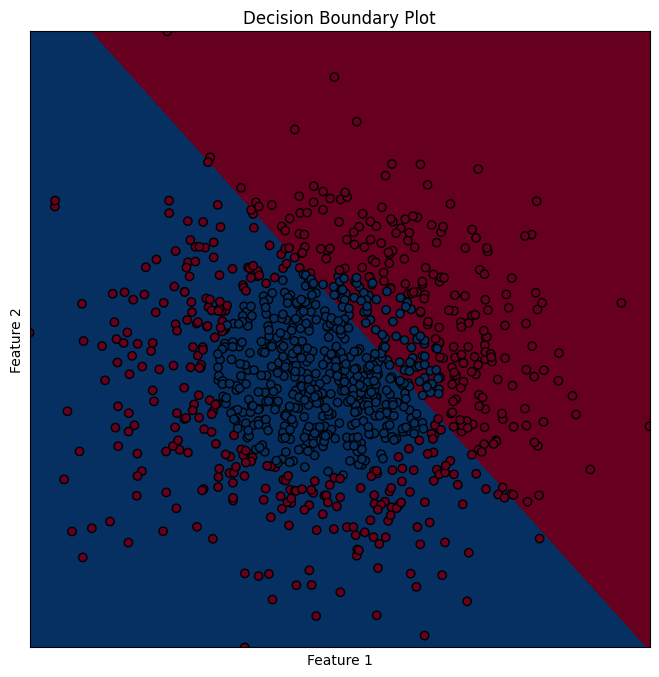

In [25]:
i = 0 #feature 1
j = 1 #feature 2

svc.fit(X[:, [i, j]], y)
fig = plt.figure(figsize=(8, 8))
ax1 = fig.add_subplot(111)

x_min, x_max = X[:,i].min(), X[:,i].max()
y_min, y_max = X[:,j].min(), X[:,j].max()
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 1000),np.linspace(y_min, y_max, 1000 ))

y_hat = svc.predict(np.concatenate((xx.reshape(-1,1), yy.reshape(-1,1)), axis = 1))
y_hat = y_hat.reshape(xx.shape)

ax1.pcolormesh(xx, yy, y_hat, cmap=plt.cm.get_cmap('RdBu_r'))
ax1.scatter(X[:, i], X[:, j], c=y, edgecolors='k', cmap=plt.cm.get_cmap('RdBu_r'))
ax1.set_xlabel('Feature 1')
ax1.set_ylabel('Feature 2')
ax1.set_title('Decision Boundary Plot')
ax1.set_xlim(xx.min(), xx.max())
ax1.set_ylim(yy.min(), yy.max())
ax1.set_xticks(())
ax1.set_yticks(())
plt.show()

Do we see the problem here?
The doughnut-shaped data are not linearly separable, i.e. a linear decision boundary is unable to adequately separate this data.


So let's make use of SVM's kernel trick to use a non-linear decision boundary instead.

Fit an SVC with a non-linear decision boundary

For the next section, we're going to use a **radial basis function kernel,** or rbf kernel, which allows the SVC to fit a non-linear decision boundary. You can read more about rbf here and about the effect of this kernel's parameters here.

Let's train a model on our synthetic data using the rbf kernel and see if it improves the accuracy:

In [28]:
svc = SVC(kernel="rbf")
svc.fit(X_train, y_train)
y_pred = svc.predict(X_test)

print("The accuracy score of the SVC is:", accuracy_score(y_test, y_pred))
print("\n\nClassification Report:\n\n",classification_report(y_test, y_pred))

The accuracy score of the SVC is: 0.9833333333333333


Classification Report:

               precision    recall  f1-score   support

           0       0.98      0.99      0.98       150
           1       0.99      0.98      0.98       150

    accuracy                           0.98       300
   macro avg       0.98      0.98      0.98       300
weighted avg       0.98      0.98      0.98       300



As we can see, this is a much better result. Let's visualise our decision boundary to see why.


Plot the decision boundary for the SVC using the non-linear rbf kernel
Once again we will plot the 1-dimensional decision boundary between the two features present in our synthetic dataset:

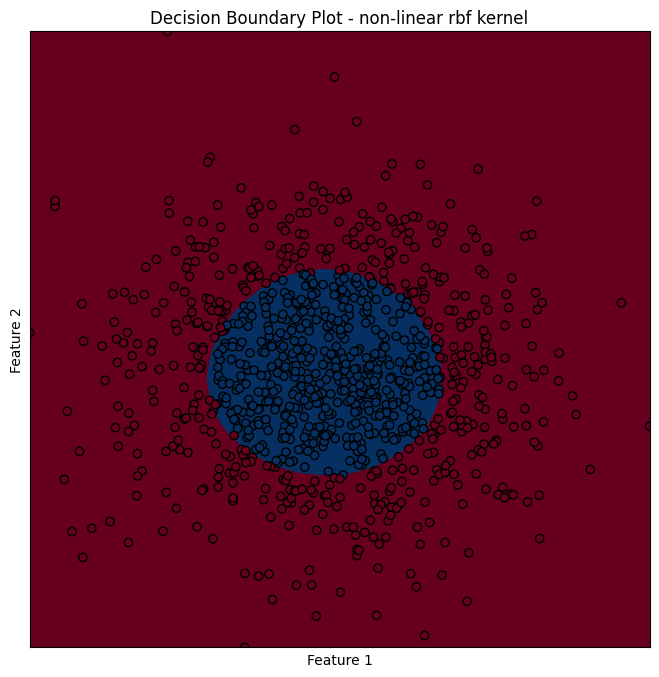

In [29]:
i = 0 #feature 1

j = 1 #feature 2

svc.fit(X[:, [i, j]], y)
fig = plt.figure(figsize=(8, 8))
ax1 = fig.add_subplot(111)

x_min, x_max = X[:, i].min(), X[:, i].max()
y_min, y_max = X[:, j].min(), X[:, j].max()
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 1000), np.linspace(y_min, y_max, 1000))

y_hat = svc.predict(np.concatenate((xx.reshape(-1,1), yy.reshape(-1,1)), axis=1))
y_hat = y_hat.reshape(xx.shape)

ax1.pcolormesh(xx, yy, y_hat, cmap=plt.cm.get_cmap('RdBu_r'))
ax1.scatter(X[:, i], X[:, j], c=y, edgecolors='k', cmap=plt.cm.get_cmap('RdBu_r'))
ax1.set_xlabel('Feature 1')
ax1.set_ylabel('Feature 2')
ax1.set_title('Decision Boundary Plot - non-linear rbf kernel')
ax1.set_xlim(xx.min(), xx.max())
ax1.set_ylim(yy.min(), yy.max())
ax1.set_xticks(())
ax1.set_yticks(())
plt.show()

Clearly the rbf kernel is a better fit to our data and results in a better-performing model. If we hadn't changed our parameters and tried a different kernel, we would have thought that our SVC did not perform well on the data and could possibly have discarded it. This highlights the importance of optimising the parameters of a model.

Optimising a model is a well-known concept and is known as model tuning. Fortunately, sklearn provides some tools for us to do this easily.

**Tuning an SVC model**


You have probably noticed that the models in the sklearn library have quite a few parameters, right? It's possible to use a process called model tuning to find the best possible set of parameters for a model. For this purpose, we will use sklearn's **GridSearchCV**. This procedure allows us to specify a set of possible parameters for a specific model. GridSearchCV will then go through those parameters and try every possible combination of them (kind of like it's working through a grid in a systematic way – that's where the name comes from). GridSearchCV will then return the combination of parameters that resulted in a model with the best score.

What metric does it use to calculate the score? It will depend on the model being tested or if we specify our own metric. You should check out exactly how this works on your own! We should also note that GridSearchCV makes use of cross-validation, helping to ensure the robustness of its results.

Let's try it out. The first thing to do is to create a dictionary that contains the parameters we want to tune as keys and all the different options we want to test for those parameters as values.

In [34]:
parameters = {'kernel':('linear', 'rbf'),
              'C':(0.25,1.0),
              'gamma': (1,2)}

Now, we instantiate an SVC classifier and tell `GridSearchCV` to test it using the parameters we previously specified:

In [35]:
svm = SVC()
clf = GridSearchCV(svm, parameters)
clf.fit(X_train,y_train)

GridSearchCV(estimator=SVC(),
             param_grid={'C': (0.25, 1.0), 'gamma': (1, 2),
                         'kernel': ('linear', 'rbf')})

In [36]:
y_opt = clf.predict(X_test)
# Print accuracy scores for tuned and untuned models
print("Accuracy for untuned model: ", accuracy_score(y_test, y_pred))
print("Accuracy for tuned model: ", accuracy_score(y_test, y_opt))

Accuracy for untuned model:  0.9833333333333333
Accuracy for tuned model:  0.9666666666666667


In [40]:
#get parameters of best performing models
print(clf.best_params_)

{'C': 1.0, 'gamma': 1, 'kernel': 'rbf'}
